# Phase 1 — Baseline Results (Technical)

Reads the committed result CSVs and renders the aggregate metric figures for the
two Phase 1 baselines on the SPY benchmark:

- **`interp_rbf`** — per-date RBF interpolation (no training)
- **`mlp`** — masked coordinate MLP

This notebook is **RunPod-independent**: every figure is derived from the
aggregate CSVs already in the repo. Per-date surface visuals (reference /
observed / reconstructed, spatial error, joint maturity×moneyness heatmap on
real data) live in `03_phase1_surface_gallery.ipynb`, which needs the benchmark
parquet (RunPod).

All plotting uses the tested `neural_iv_surface_inference.viz` module.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Resolve repo root whether the notebook runs from repo root or notebooks/.
ROOT = Path.cwd().resolve()
if not (ROOT / "artifacts").exists() and (ROOT.parent / "artifacts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from neural_iv_surface_inference.viz import (
    apply_house_style,
    plot_baseline_comparison,
    plot_observed_vs_unobserved,
    plot_regional_error_bars,
    plot_noise_sweep,
)

apply_house_style()
RESULTS = ROOT / "artifacts" / "results"
print("repo root:", ROOT)

repo root: /Users/mengziyue/Neural IV Surface inference


In [2]:
results_df = pd.read_csv(RESULTS / "baseline_results.csv")
print("models:", sorted(results_df["model"].unique()))
print("splits:", sorted(results_df["split"].unique()))
results_df.head()

models: ['interp_rbf', 'mlp']
splits: ['test', 'train', 'val']


,model,overall_mae,overall_rmse,overall_mape,overall_n,observed_mae,observed_rmse,observed_mape,observed_n,unobserved_mae,...,by_moneyness_atm_mae,by_moneyness_atm_rmse,by_moneyness_atm_n,by_moneyness_otm_mae,by_moneyness_otm_rmse,by_moneyness_otm_n,by_moneyness_deep_otm_mae,by_moneyness_deep_otm_rmse,by_moneyness_deep_otm_n,split
0,interp_rbf,0.050670,0.089747,116.916779,10458763,0.039069,0.065870,87.230670,4181593,0.058398,...,0.019507,0.028946,2612740,0.037431,0.051850,1744331,0.054793,0.081129,838921,train
1,interp_rbf,0.045201,0.088577,82.995215,5617807,0.037803,0.070646,68.121591,2245429,0.050127,...,0.015518,0.025454,1380079,0.036529,0.054186,1116266,0.059924,0.082002,513388,val
2,interp_rbf,0.068656,0.113742,151.251980,5310219,0.056236,0.090119,121.110458,2123945,0.076936,...,0.019767,0.031423,1491961,0.056390,0.072033,771621,0.119685,0.137964,371744,test
3,mlp,0.097574,0.163173,276.741943,10458763,0.097489,0.163105,276.635468,4181593,0.097630,...,0.051388,0.079756,2612740,0.073609,0.115494,1744331,0.127652,0.195183,838921,train
4,mlp,0.100624,0.165762,172.370483,5617807,0.100594,0.165714,172.135590,2245429,0.100644,...,0.052543,0.069120,1380079,0.072638,0.121197,1116266,0.114198,0.205226,513388,val


## 1. Headline comparison (test split)

Overall and unobserved MAE for both baselines. Unobserved error is the one that
matters for surface *inference* — it measures reconstruction at points the model
never saw.

In [3]:
cols = ["model", "split", "overall_mae", "overall_rmse",
        "observed_mae", "unobserved_mae"]
summary = results_df[results_df["split"] == "test"][cols].reset_index(drop=True)
summary

,model,split,overall_mae,overall_rmse,observed_mae,unobserved_mae
0,interp_rbf,test,0.068656,0.113742,0.056236,0.076936
1,mlp,test,0.096656,0.166192,0.096595,0.096696


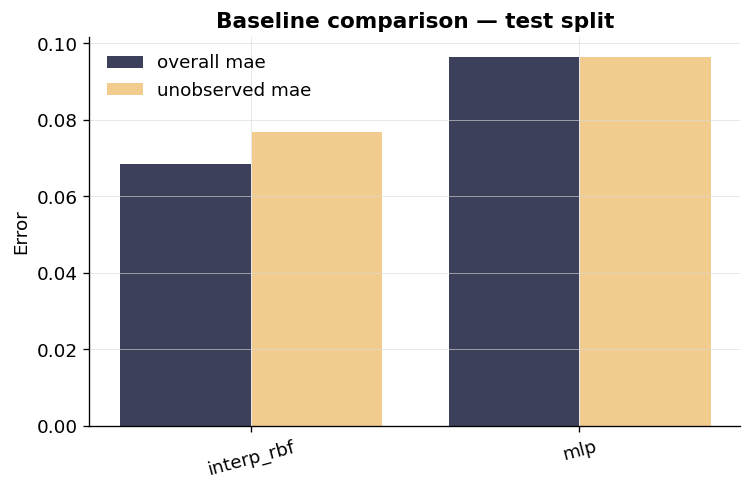

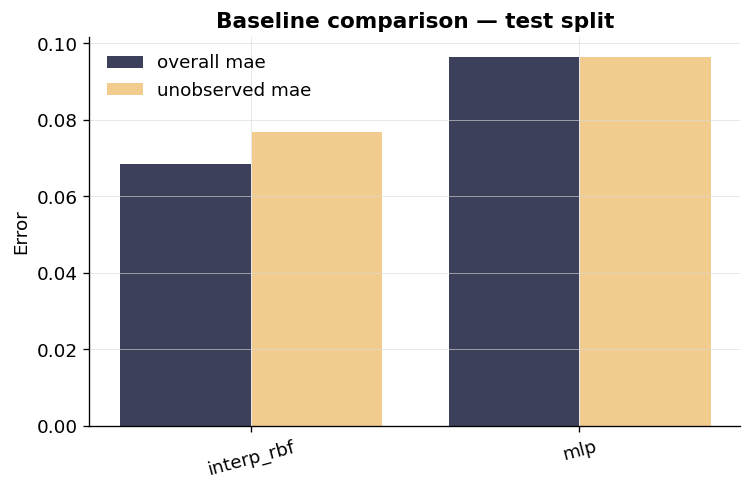

In [4]:
fig = plot_baseline_comparison(results_df, split="test")
fig

## 2. Observed vs unobserved gap

A model that has learned surface *structure* should reconstruct unobserved
points nearly as well as observed ones. A flat observed≈unobserved profile means
the model only fits a smooth global average and does not exploit local structure.

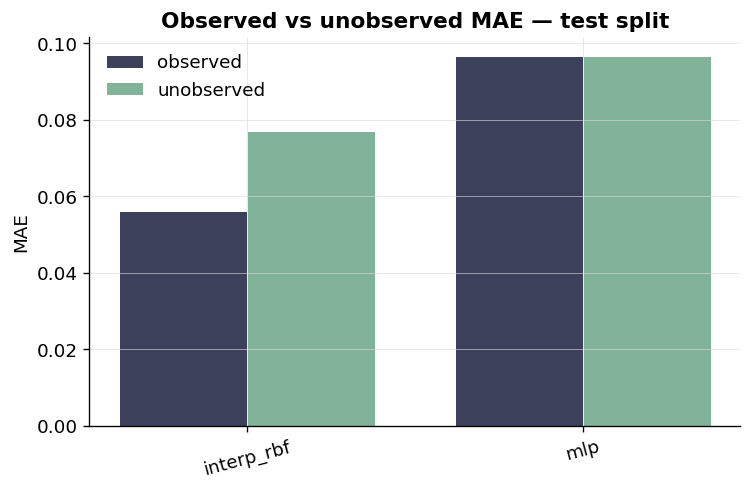

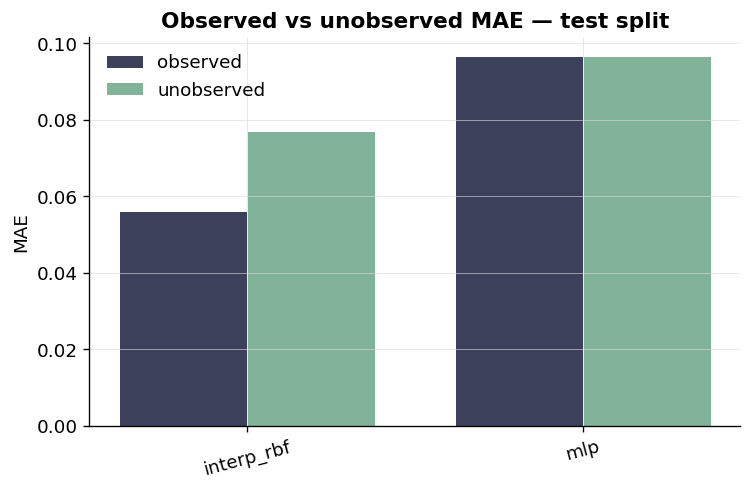

In [5]:
fig = plot_observed_vs_unobserved(results_df, split="test")
fig

## 3. Regional breakdown

Where does each model fail? Error stratified by moneyness bucket
(deep-ITM → deep-OTM) and maturity bucket (short / medium / long).

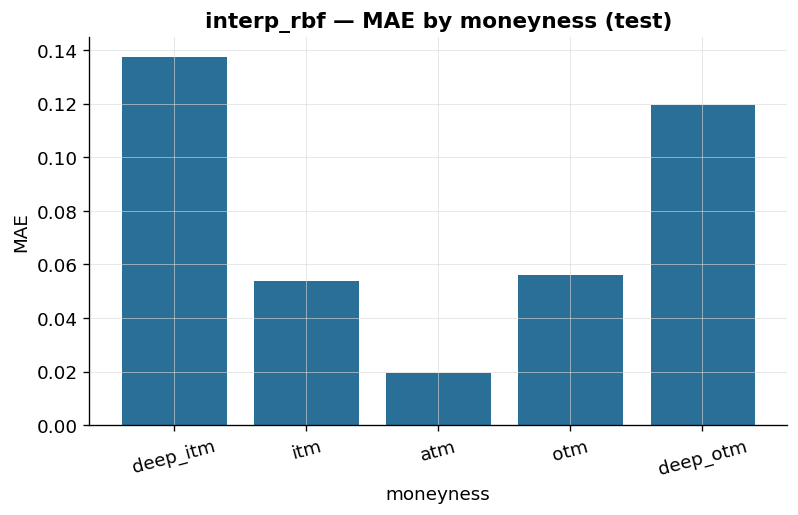

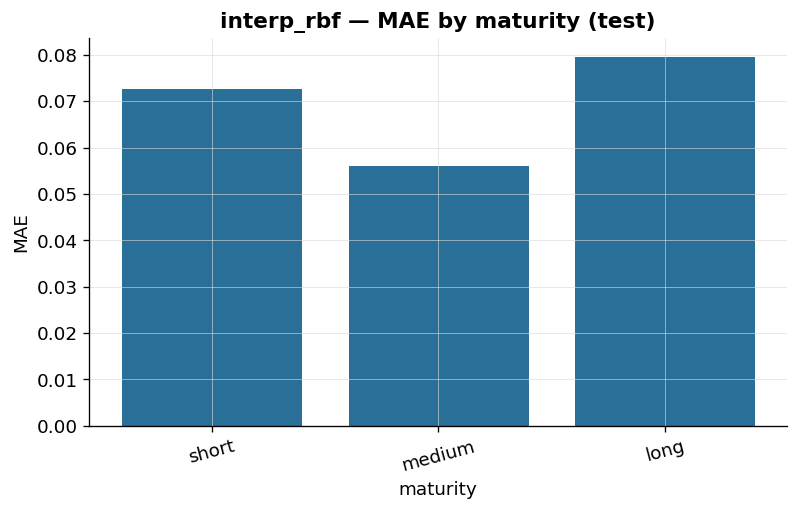

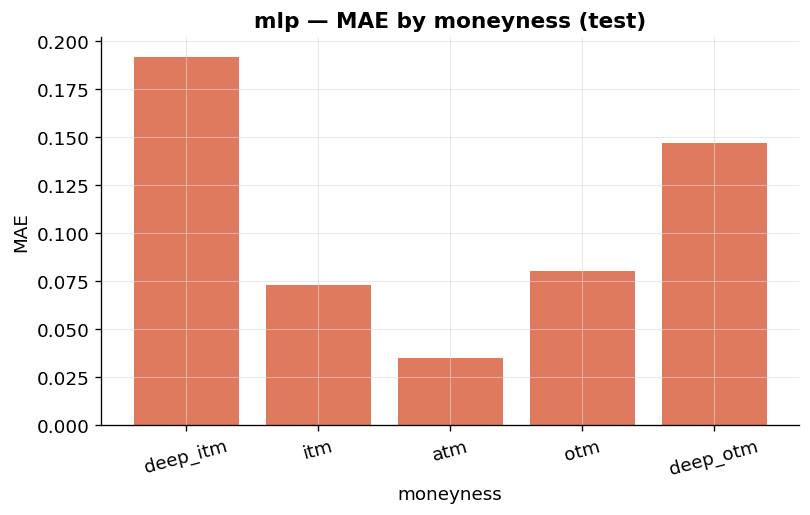

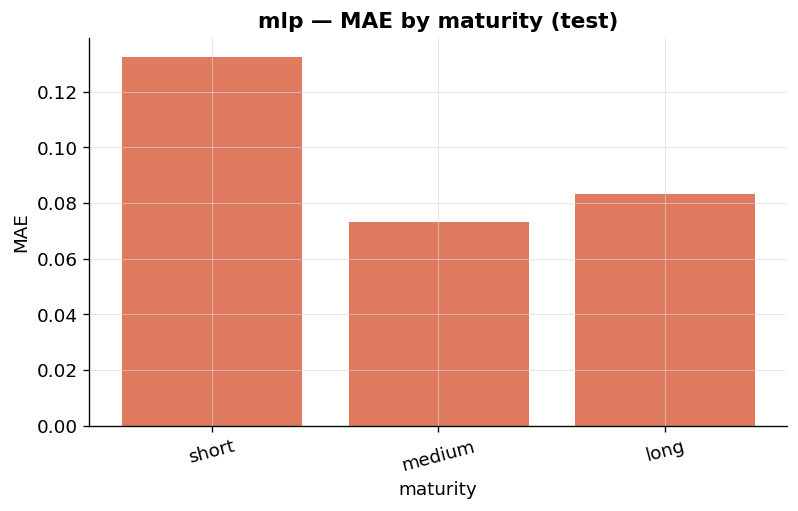

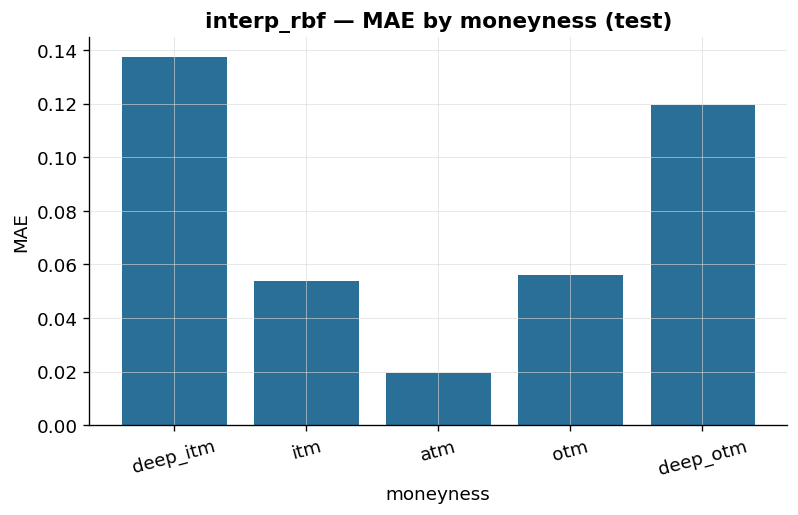

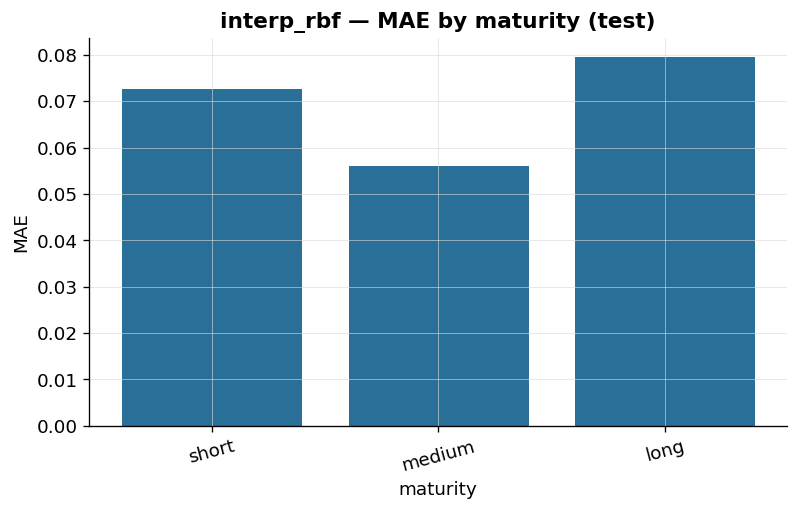

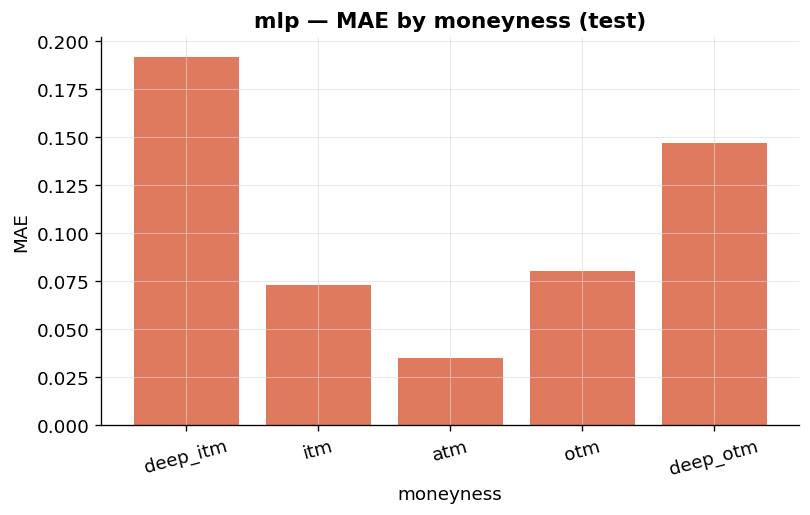

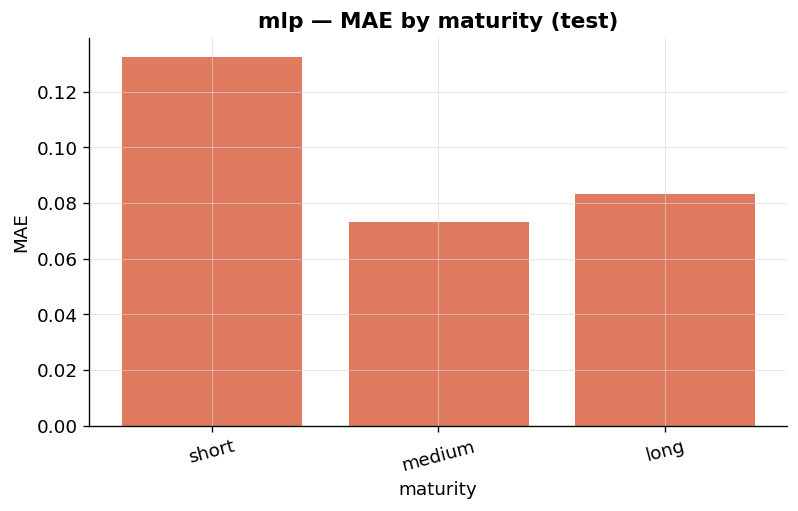

In [6]:
for model in sorted(results_df["model"].unique()):
    display(plot_regional_error_bars(results_df, model=model, dimension="moneyness"))
    display(plot_regional_error_bars(results_df, model=model, dimension="maturity"))

## 4. Noise sensitivity

Interpolation error across low / medium / high observation-noise regimes
(sampled test sweep). Loaded only if the sweep CSV is present.

,variant,n_rows,n_dates,overall_mae,overall_rmse,observed_mae,unobserved_mae
0,random40_noiselow,937868,120,0.070133,0.116591,0.057204,0.078750
1,random40_noisemed,937868,120,0.071085,0.116917,0.058395,0.079542
2,random40_noisehigh,937868,120,0.072792,0.117679,0.060417,0.081040


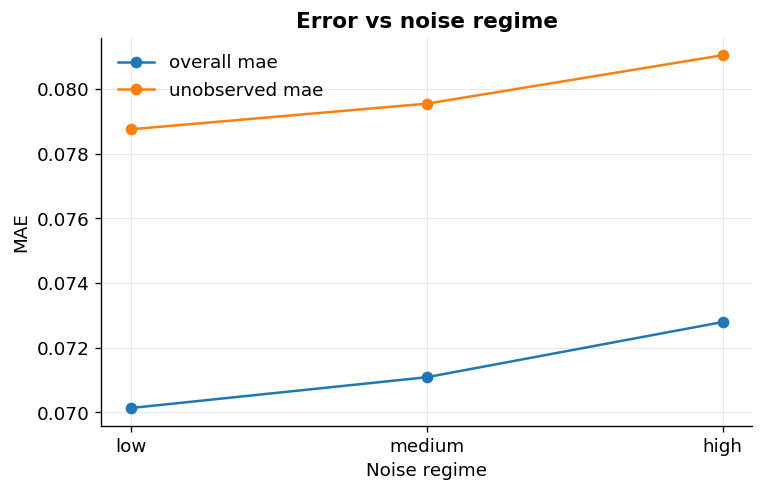

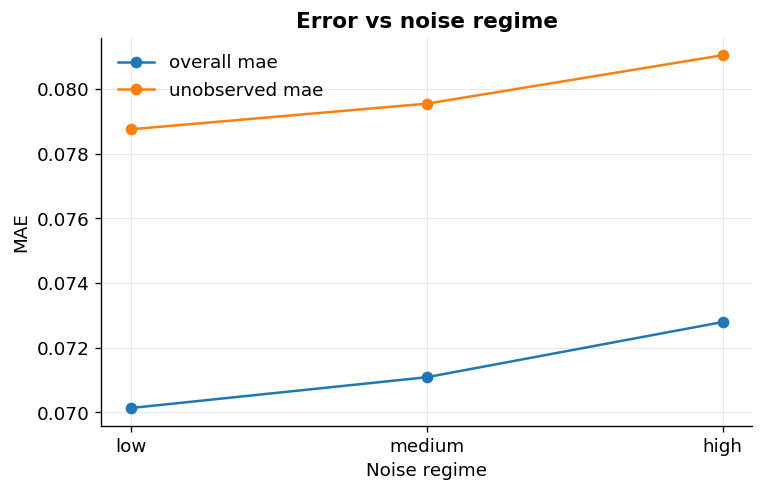

In [7]:
sweep_path = RESULTS / "interp_sweep_sampled_test.csv"
if sweep_path.exists():
    sweep_df = pd.read_csv(sweep_path)
    display(sweep_df)
    if "variant" in sweep_df.columns:
        display(plot_noise_sweep(sweep_df))
    else:
        print("sweep CSV present but has no 'variant' column; skipping plot.")
else:
    print("No noise-sweep CSV found; skipping.")

## 5. Interpretation

- On the SPY test benchmark, **per-date RBF interpolation beats the coordinate
  MLP** on overall MAE (≈0.069 vs ≈0.097).
- The MLP's **observed and unobserved MAE are nearly equal** (≈0.097 both): it
  learned a smooth global fit, not local surface structure, so it gains nothing
  on the points it actually saw.
- Both models are **worst at short maturity and the deep wings** (deep-ITM /
  deep-OTM), exactly the economically hardest regions.
- Error rises monotonically with observation noise, as expected.

**Takeaway for Phase 2:** pursue structured / mask-aware surface-level models
rather than a plain coordinate-regression MLP. The joint maturity×moneyness
heatmap and the surface reconstruction visuals (notebook 03, RunPod) make the
*spatial* failure modes concrete.